Load Necessary Packages

In [86]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import nltk
from nltk.stem import SnowballStemmer

from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, precision_score, accuracy_score

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

import re, warnings
warnings.filterwarnings("ignore")
from sklearn.ensemble import RandomForestClassifier

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import warnings

from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED)

In [87]:
# Uncomment and run once:
# !pip install bertopic datasets sentence-transformers umap-learn hdbscan plotly

# Verify installation
import bertopic
print(f"✅ BERTopic version: {bertopic.__version__}")

✅ BERTopic version: 0.17.4


In [88]:
df = pd.read_csv('data.csv', skiprows=[1, 2])
df = df.reset_index(drop=True)
print("Shape:", df.shape)

Shape: (94, 46)


In [89]:
likert_map = {
    'Strongly disagree': 1,
    'Disagree':          2,
    'Neutral':           3,
    'Agree':             4,
    'Strongly agree':    5,
}
 
likert_cols = [
    'interaction', 'comparison', 'lose_track', 'consume', 'drained',
    'comment_msg', 'relationships', 'create', 'connected',
    'anxious', 'lonely', 'down', 'unable_relax',
    'ai_stressed', 'ai_post_social', 'ai_less_lonely', 'ai_judgmental', 'ai_mood_imp'
]
 
for col in likert_cols:
    df[col] = df[col].map(likert_map)

In [90]:
# High concern = average ≥ 3 across: anxious, lonely, down, unable_relax
mental_health_cols = ['anxious', 'lonely', 'down', 'unable_relax']
df['mh_score']   = df[mental_health_cols].mean(axis=1)
df['mh_concern'] = (df['mh_score'] >= 3.0).astype(int)   # 1 = concern, 0 = no concern
 
print("\nTarget distribution:")
print(df['mh_concern'].value_counts())


Target distribution:
mh_concern
0    56
1    38
Name: count, dtype: int64


In [91]:
time_order = {
    'Less than 30 minutes': 0,
    '30 minutes to 1 hour': 1,
    '1-2 hours':            2,
    '2–4 hours':            3,
    '4–6 hours':            4,
    'More than 6 hours':    5,
}
df['time_enc']   = df['time'].map(time_order).fillna(2)
df['gender_enc'] = LabelEncoder().fit_transform(df['gender'].fillna('Unknown'))

BERTopic

In [92]:
FREE_RESPONSE_COLS = ['effect_social_media', 'ai_emotional_support']
 
print("Loading sentence transformer...")
emb_model = SentenceTransformer('all-MiniLM-L6-v2')
 
raw_embeddings = {}
for col in FREE_RESPONSE_COLS:
    texts = df[col].fillna('no response').astype(str).tolist()
    raw_embeddings[col] = emb_model.encode(texts, show_progress_bar=False,
                                            convert_to_numpy=True)
    print(f"Encoded '{col}': {raw_embeddings[col].shape}")

Loading sentence transformer...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoded 'effect_social_media': (94, 384)
Encoded 'ai_emotional_support': (94, 384)


In [93]:
# Key fixes vs default BERTopic:
#   - UMAP n_neighbors=10 (default 15 is too large for n=94)
#   - HDBSCAN min_cluster_size=5, min_samples=2 (allows smaller clusters)
#   - nr_topics set to a small fixed number to avoid all-outlier result
topic_feature_frames = []
 
for col in FREE_RESPONSE_COLS:

    umap_model    = UMAP(n_neighbors=10, n_components=5, metric='cosine', random_state=42, min_dist=0.0)
    hdbscan_model = HDBSCAN(min_cluster_size=5, min_samples=2, metric='euclidean', prediction_data=True)

    print(f"\n── BERTopic on '{col}' ──")
    texts = df[col].fillna('no response').astype(str).tolist()
 
    topic_model = bertopic.BERTopic(
        embedding_model=emb_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        nr_topics=6,          # force merge down to max 6 topics
        verbose=False,
    )
    topics, probs = topic_model.fit_transform(texts, raw_embeddings[col])
 
    info = topic_model.get_topic_info()
    print(info[['Topic','Count','Name']].to_string(index=False))
 
    outlier_pct = (np.array(topics) == -1).mean()
    print(f"Outlier rate: {outlier_pct:.0%}")
 
    # Strategy: use soft probabilities if available, else hard topic label
    # For n=94, soft probs are more informative than a single integer label
    if probs is not None and np.array(probs).ndim == 2 and np.array(probs).shape[1] > 1:
        prob_arr  = np.array(probs)
        prob_cols = [f'{col}_topic_prob_{i}' for i in range(prob_arr.shape[1])]
        topic_feature_frames.append(
            pd.DataFrame(prob_arr, columns=prob_cols)
        )
        print(f"Using {prob_arr.shape[1]} soft probability features")
    else:
        # Fallback: PCA on raw embeddings (always has variance, never all-outlier)
        print("Soft probs unavailable — falling back to PCA on raw embeddings")
        pca = PCA(n_components=10, random_state=42)
        reduced = pca.fit_transform(raw_embeddings[col])
        pca_cols = [f'{col}_pca_{i}' for i in range(reduced.shape[1])]
        topic_feature_frames.append(pd.DataFrame(reduced, columns=pca_cols))


── BERTopic on 'effect_social_media' ──
 Topic  Count                            Name
    -1      2 -1_ways_motivates_bright_making
     0     36              0_it_me_makes_feel
     1     26            1_media_social_to_my
     2     14        2_to_helps_myself_others
     3      9       3_viedo_unsure_yes_rarely
     4      7    4_makes_me_unproductive_feel
Outlier rate: 2%
Soft probs unavailable — falling back to PCA on raw embeddings

── BERTopic on 'ai_emotional_support' ──
 Topic  Count           Name
     0     14 0_no_yes_bruh_
     1     80 1_to_no_it_not
Outlier rate: 0%
Soft probs unavailable — falling back to PCA on raw embeddings


In [94]:
likert_features = [
    'interaction', 'comparison', 'lose_track', 'consume', 'drained',
    'comment_msg', 'relationships', 'create', 'connected',
    'ai_stressed', 'ai_post_social', 'ai_less_lonely', 'ai_judgmental', 'ai_mood_imp',
    'time_enc', 'gender_enc',
]
 
df_topic_features = pd.concat(topic_feature_frames, axis=1)
text_feature_cols = list(df_topic_features.columns)
 
df_model = pd.concat(
    [df[likert_features + ['mh_concern']].reset_index(drop=True), df_topic_features],
    axis=1
)
 
print(f"\nFinal modelling shape: {df_model.shape}")
print(f"Class balance — 0: {(df_model.mh_concern==0).sum()}  1: {(df_model.mh_concern==1).sum()}")
 
all_features   = likert_features + text_feature_cols
X = df_model[all_features]
y = df_model['mh_concern']


Final modelling shape: (94, 37)
Class balance — 0: 56  1: 38


In [95]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
configs = {
    'RF — Likert only':            (RandomForestClassifier(n_estimators=500, max_depth=4,
                                     min_samples_leaf=3, random_state=42, class_weight='balanced'),
                                    likert_features),
    'RF — Likert + text features': (RandomForestClassifier(n_estimators=500, max_depth=4,
                                     min_samples_leaf=3, random_state=42, class_weight='balanced'),
                                    all_features),
    'LR — Likert + text features': (LogisticRegression(C=0.5, max_iter=1000,
                                     class_weight='balanced', random_state=42),
                                    all_features),
}
 
print("\n=== Model Comparison (5-fold CV) ===")
for name, (clf, feats) in configs.items():
    acc = cross_val_score(clf, df_model[feats], y, cv=cv, scoring='accuracy').mean()
    f1  = cross_val_score(clf, df_model[feats], y, cv=cv, scoring='f1').mean()
    roc = cross_val_score(clf, df_model[feats], y, cv=cv, scoring='roc_auc').mean()
    print(f"{name:<38} Accuracy={acc:.3f}  F1={f1:.3f}  ROC-AUC={roc:.3f}")


=== Model Comparison (5-fold CV) ===
RF — Likert only                       Accuracy=0.606  F1=0.409  ROC-AUC=0.617
RF — Likert + text features            Accuracy=0.520  F1=0.252  ROC-AUC=0.494
LR — Likert + text features            Accuracy=0.618  F1=0.540  ROC-AUC=0.634


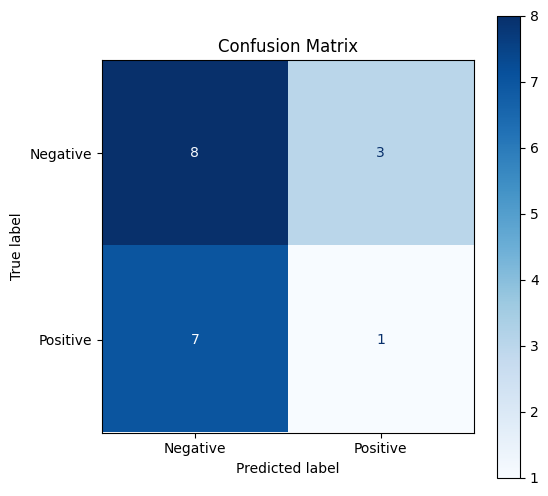

In [105]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Select model + features
rf = RandomForestClassifier(
    n_estimators=500, max_depth=4,
    min_samples_leaf=3, random_state=42,
    class_weight='balanced'
)

features = all_features

X = df_model[features]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    df_model[all_features],
    df_model['mh_concern'],
    test_size=0.2,
    stratify=df_model['mh_concern'],
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot(cmap="Blues", ax=ax)

plt.title("Confusion Matrix")
plt.show()

In [106]:
importances = (
    pd.Series(rf.feature_importances_, index=all_features)
    .sort_values(ascending=False)
)
 
print("\n=== Feature Importances ===")
for feat, imp in importances.items():
    bar = '█' * int(imp * 80)
    print(f"  {feat:<25} {imp:.4f}  {bar}")
 


=== Feature Importances ===
  ai_emotional_support_pca_9 0.1040  ████████
  effect_social_media_pca_0 0.0581  ████
  effect_social_media_pca_6 0.0579  ████
  effect_social_media_pca_1 0.0557  ████
  ai_emotional_support_pca_6 0.0440  ███
  effect_social_media_pca_2 0.0414  ███
  comparison                0.0408  ███
  effect_social_media_pca_3 0.0386  ███
  ai_emotional_support_pca_3 0.0379  ███
  drained                   0.0366  ██
  ai_emotional_support_pca_1 0.0344  ██
  ai_emotional_support_pca_0 0.0326  ██
  effect_social_media_pca_7 0.0325  ██
  effect_social_media_pca_5 0.0323  ██
  ai_emotional_support_pca_2 0.0310  ██
  effect_social_media_pca_4 0.0294  ██
  effect_social_media_pca_9 0.0293  ██
  ai_stressed               0.0279  ██
  ai_emotional_support_pca_5 0.0260  ██
  ai_emotional_support_pca_8 0.0257  ██
  ai_emotional_support_pca_7 0.0221  █
  effect_social_media_pca_8 0.0211  █
  ai_emotional_support_pca_4 0.0194  █
  ai_post_social            0.0183  █
  relationsh

In [107]:
rf = RandomForestClassifier(n_estimators=500, max_depth=4,
                             min_samples_leaf=3, random_state=42,
                             class_weight='balanced')
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=all_features).sort_values(ascending=False)
 
print("\n=== Top 15 Feature Importances ===")
for feat, imp in importances.head(15).items():
    bar  = '█' * int(imp * 80)
    kind = '(text)' if any(feat.startswith(c) for c in FREE_RESPONSE_COLS) else ''
    print(f"  {feat:<40} {imp:.4f}  {bar} {kind}")


=== Top 15 Feature Importances ===
  drained                                  0.0834  ██████ 
  effect_social_media_pca_6                0.0701  █████ (text)
  ai_emotional_support_pca_9               0.0591  ████ (text)
  effect_social_media_pca_1                0.0568  ████ (text)
  effect_social_media_pca_0                0.0556  ████ (text)
  comparison                               0.0506  ████ 
  ai_emotional_support_pca_3               0.0479  ███ (text)
  effect_social_media_pca_3                0.0433  ███ (text)
  ai_emotional_support_pca_6               0.0378  ███ (text)
  effect_social_media_pca_2                0.0363  ██ (text)
  ai_emotional_support_pca_2               0.0327  ██ (text)
  effect_social_media_pca_5                0.0318  ██ (text)
  effect_social_media_pca_4                0.0317  ██ (text)
  ai_emotional_support_pca_8               0.0309  ██ (text)
  effect_social_media_pca_9                0.0298  ██ (text)


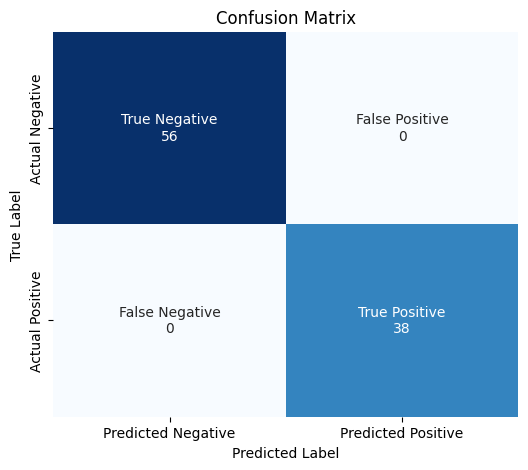

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Actual + predicted labels
y_true = df_model['mh_concern']
y_pred = rf.predict(X)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Create labels with counts
labels = np.array([
    [f"True Negative\n{cm[0,0]}", f"False Positive\n{cm[0,1]}"],
    [f"False Negative\n{cm[1,0]}", f"True Positive\n{cm[1,1]}"]
])

# Plot
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted Negative", "Predicted Positive"],
    yticklabels=["Actual Negative", "Actual Positive"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()